# Customer Sentiment on Twitter: `sample.csv` Colab Version

**Prepared:** Armin Kajevic, Senior Management Consultant

> This notebook is designed specifically for the supplied `sample.csv` file. It never expects `train.csv`.

Run the cells from top to bottom. In the upload cell, choose the supplied file named **`sample.csv`**. The notebook will stop with a clear message if a different file is selected.


In [1]:
# 1. Keep the Google Colab base environment unchanged
# Google Colab already includes pandas, matplotlib, seaborn, and torch.
# Install only the NLP packages required for the Hugging Face model.
# Package output is captured so unrelated Colab package warnings do not obscure the result.
import subprocess
import sys

install = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", "transformers==4.48.3", "sentencepiece>=0.2.0"],
    text=True,
    capture_output=True,
)
if install.returncode != 0:
    raise RuntimeError("Required NLP packages could not be installed. Open the cell output for details: " + install.stderr[-1000:])

import pandas as pd
import matplotlib
import seaborn as sns
import torch
import transformers

print("Setup complete. Colab pandas and torch were not changed.")
print(f"pandas={pd.__version__} | torch={torch.__version__} | transformers={transformers.__version__}")


Setup complete. Colab pandas and torch were not changed.
pandas=2.2.2 | torch=2.11.0+cpu | transformers=4.48.3


In [4]:
# 2. Upload the supplied file named sample.csv
from pathlib import Path
from google.colab import files

EXPECTED_FILE = "sample.csv"

if not Path(EXPECTED_FILE).exists():
    print("Select the supplied sample.csv file now.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No file was uploaded. Please run this cell again and select sample.csv.")

    csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
    if EXPECTED_FILE not in uploaded:
        available = ", ".join(csv_files) if csv_files else "no CSV file"
        raise FileNotFoundError(
            f"This notebook requires '{EXPECTED_FILE}'. You uploaded: {available}. "
            "Rename or select the supplied file, then run this cell again."
        )

if not Path(EXPECTED_FILE).exists():
    raise FileNotFoundError(f"{EXPECTED_FILE} is still missing from /content. Re-run the upload cell.")

print(f"Ready: /content/{EXPECTED_FILE}")


Ready: /content/sample.csv


In [5]:
# 3. Load sample.csv - this replaces any old /content/train.csv code
import pandas as pd
from IPython.display import display

DATA_PATH = "/content/sample.csv"
df = pd.read_csv(DATA_PATH)

expected_columns = {
    "tweet_id", "author_id", "inbound", "created_at", "text",
    "response_tweet_id", "in_response_to_tweet_id",
}
missing_columns = expected_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"sample.csv is missing expected columns: {sorted(missing_columns)}")

print(f"Data loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())


Data loaded successfully: 93 rows, 7 columns


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,119237,105834,True,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...,119236,NaN
1,119238,ChaseSupport,False,Wed Oct 11 13:25:49 +0000 2017,@105835 Your business means a lot to us. Pleas...,NaN,119239.0
2,119239,105835,True,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...,119238,NaN
3,119240,VirginTrains,False,Tue Oct 10 15:16:08 +0000 2017,@105836 LiveChat is online at the moment - htt...,119241,119242.0
4,119241,105836,True,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...,119243,119240.0


,data_type,missing_values,missing_rate
tweet_id,int64,0,0.0
author_id,object,0,0.0
inbound,bool,0,0.0
created_at,object,0,0.0
text,object,0,0.0
response_tweet_id,object,28,30.1
in_response_to_tweet_id,float64,25,26.9
is_inbound,bool,0,0.0
created_at_parsed,"datetime64[ns, UTC]",0,0.0


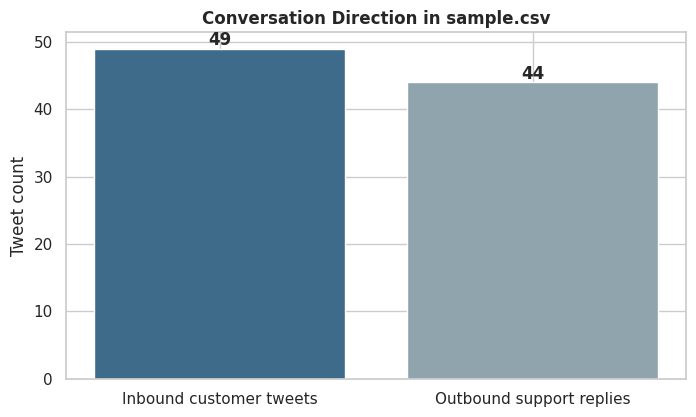

In [6]:
# 4. Profile the supplied sample
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = df.copy()
df["is_inbound"] = df["inbound"].astype(str).str.strip().str.lower().eq("true")
df["created_at_parsed"] = pd.to_datetime(
    df["created_at"], format="%a %b %d %H:%M:%S %z %Y", utc=True, errors="coerce"
)

profile = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_rate": (df.isna().mean() * 100).round(1),
})
display(profile)

counts = pd.Series({
    "Inbound customer tweets": int(df["is_inbound"].sum()),
    "Outbound support replies": int((~df["is_inbound"]).sum()),
})
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index, counts.values, color=["#3E6B89", "#90A4AE"])
ax.set_title("Conversation Direction in sample.csv", fontweight="bold")
ax.set_ylabel("Tweet count")
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom", fontweight="bold")
plt.show()


## Optional Gemini Exploration

Gemini is optional because it requires your own Google AI key. The core analysis below works without it. To use Gemini, add `GEMINI_API_KEY` in **Colab Secrets**, then run the optional cell.


In [7]:
# 5. Optional Gemini initial exploration - safe to skip
# This cell never blocks the rest of the notebook.
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

if GEMINI_API_KEY:
    !pip -q install "google-genai>=1.0"
    from google import genai
    profile_text = profile.to_csv()
    preview_text = df[["tweet_id", "inbound", "created_at", "text"]].head(5).to_csv(index=False)
    prompt = f"Analyze this dataset profile. Describe the columns, missingness, and three careful hypotheses. Separate facts from hypotheses.\n\nPROFILE:\n{profile_text}\nPREVIEW:\n{preview_text}"
    client = genai.Client(api_key=GEMINI_API_KEY)
    response = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    print(response.text)
else:
    print("Gemini skipped: add GEMINI_API_KEY to Colab Secrets only if you want this optional step.")


Gemini skipped: add GEMINI_API_KEY to Colab Secrets only if you want this optional step.


In [8]:
# 6. Hugging Face sentiment analysis for inbound customer tweets
import html
from transformers import pipeline
import torch

inbound = df.loc[df["is_inbound"]].copy()

def clean_tweet(text: object) -> str:
    cleaned = []
    for token in html.unescape(str(text or "")).split():
        if token.startswith("@"):
            cleaned.append("@user")
        elif token.startswith("http"):
            cleaned.append("http")
        else:
            cleaned.append(token)
    return " ".join(cleaned)

inbound["text_for_model"] = inbound["text"].map(clean_tweet)
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("text-classification", model=model_name, tokenizer=model_name, device=device)
results = classifier(inbound["text_for_model"].tolist(), batch_size=8, truncation=True, max_length=128)

label_map = {"LABEL_0": "Negative", "LABEL_1": "Neutral", "LABEL_2": "Positive"}
inbound["sentiment"] = [label_map.get(result["label"], result["label"]) for result in results]
inbound["confidence"] = [round(float(result["score"]), 4) for result in results]

print(f"Scored {len(inbound)} inbound customer tweets.")
display(inbound[["text", "sentiment", "confidence"]].head(10))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


Scored 49 inbound customer tweets.


,text,sentiment,confidence
0,@AppleSupport causing the reply to be disregar...,negative,0.8924
2,@76328 I really hope you all change but I'm su...,negative,0.4329
4,@VirginTrains see attached error message. I've...,negative,0.7300
6,"@VirginTrains yep, I've tried laptop too sever...",neutral,0.7323
8,@VirginTrains I still haven't heard &amp; the ...,negative,0.8978
11,"@105838 @AppleSupport Me too am suffering , ho...",negative,0.7125
12,"@AppleSupport hi #apple, I’ve a concern about ...",negative,0.9124
14,I just updated my phone and suddenly everythin...,negative,0.9567
16,@SpotifyCares Thanks! Version 8.4.22.857 armv7...,neutral,0.6005
18,"@SpotifyCares No, but I've moved speaker to ab...",neutral,0.4883


,sentiment,tweets,share
0,Negative,0,0.0%
1,Neutral,0,0.0%
2,Positive,0,0.0%


/tmp/ipykernel_805/845601326.py:12: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(summary.values) * 1.22)


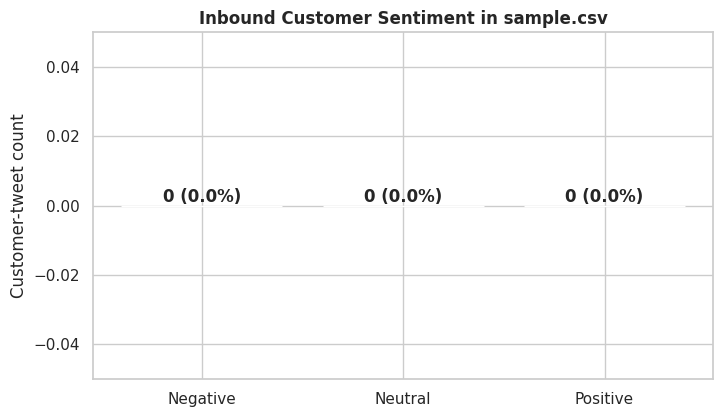

Important: model sentiment is a text signal, not a customer-satisfaction or business-impact score.


In [9]:
# 7. Present the sentiment result
summary = inbound["sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"], fill_value=0)
summary_df = summary.rename_axis("sentiment").reset_index(name="tweets")
summary_df["share"] = summary_df["tweets"] / len(inbound)
display(summary_df.style.format({"share": "{:.1%}"}))

colors = {"Negative": "#B33A3A", "Neutral": "#8E99A3", "Positive": "#2E7D5A"}
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(summary.index, summary.values, color=[colors[label] for label in summary.index])
ax.set_title("Inbound Customer Sentiment in sample.csv", fontweight="bold")
ax.set_ylabel("Customer-tweet count")
ax.set_ylim(0, max(summary.values) * 1.22)
for bar, count in zip(bars, summary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count, f"{int(count)} ({count / len(inbound):.1%})", ha="center", va="bottom", fontweight="bold")
plt.show()

print("Important: model sentiment is a text signal, not a customer-satisfaction or business-impact score.")


In [10]:
# 8. Save the results from sample.csv
inbound.to_csv("sample_scored_inbound_tweets.csv", index=False)
summary_df.to_csv("sample_sentiment_summary.csv", index=False)
print("Saved: sample_scored_inbound_tweets.csv and sample_sentiment_summary.csv")


Saved: sample_scored_inbound_tweets.csv and sample_sentiment_summary.csv
